# Prediction of CO2 emissions from country-specific data
## Data Exploration and visualization

### Import libaries and dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor


data=pd.read_csv(r'data_cleaned_asian_countries.csv')


In [2]:
# Shape of the data
print("Shape of the dataset:", data.shape)

Shape of the dataset: (352, 18)


In [3]:
# Number of features/columns and datatypes
print("available columns and their datatypes : ")
data.dtypes

available columns and their datatypes : 


country                 object
year                     int64
cereal_yield           float64
fdi_perc_gdp           float64
en_per_gdp             float64
en_per_cap             float64
co2_ttl                float64
co2_per_cap            float64
co2_per_gdp            float64
pop_urb_aggl_perc      float64
prot_area_perc         float64
gdp                    float64
gni_per_cap            float64
under_5_mort_rate      float64
pop_growth_perc        float64
pop                    float64
urb_pop_growth_perc    float64
urb_pop                float64
dtype: object

In [4]:
print("Overview of dataset")
data.head()

Overview of dataset


,country,year,cereal_yield,fdi_perc_gdp,en_per_gdp,en_per_cap,co2_ttl,co2_per_cap,co2_per_gdp,pop_urb_aggl_perc,prot_area_perc,gdp,gni_per_cap,under_5_mort_rate,pop_growth_perc,pop,urb_pop_growth_perc,urb_pop
0,BGD,1991,2585.7,0.004491,154.496130,116.511476,15940.449,0.147913,196.135682,9.443704,1.537922,3.095744e+10,300.0,137.9,2.359199,107768749.0,4.260207,2.174773e+07
1,BGD,1992,2625.6,0.011738,155.245750,120.235439,17748.280,0.161018,207.903214,9.630124,1.537948,3.170886e+10,320.0,132.1,2.254105,110225555.0,4.119647,2.266237e+07
2,BGD,1993,2647.7,0.042362,156.704434,124.190376,17407.249,0.154531,194.988857,9.827585,1.537974,3.316653e+10,320.0,125.6,2.171660,112645460.0,4.003036,2.358796e+07
3,BGD,1994,2475.8,0.033012,157.245677,126.988772,18969.391,0.164867,204.148470,10.035264,1.538000,3.376866e+10,320.0,119.5,2.119981,115059015.0,3.918420,2.453058e+07
4,BGD,1995,2593.1,0.004998,163.051742,135.307621,22816.074,0.194201,234.020802,10.250997,1.538026,3.793975e+10,330.0,113.9,2.088211,117486952.0,3.854877,2.549467e+07


In [5]:
print("Descriptive statistics of the dataset:")
data.describe().T

Descriptive statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
year,352.0,1.999673e+03,5.121161e+00,1.991000e+03,1.995000e+03,2.000000e+03,2.004000e+03,2.008000e+03
cereal_yield,352.0,3.037893e+03,1.514083e+03,5.611000e+02,2.028400e+03,2.662850e+03,4.022175e+03,7.072800e+03
fdi_perc_gdp,352.0,2.374726e+00,3.232991e+00,-5.138922e+00,4.222911e-01,1.268699e+00,3.576433e+00,2.265197e+01
en_per_gdp,352.0,2.768914e+02,2.254720e+02,1.080062e+02,1.553609e+02,2.259194e+02,2.839868e+02,1.383380e+03
en_per_cap,352.0,1.658977e+03,1.432860e+03,1.165115e+02,4.922395e+02,1.081310e+03,2.528653e+03,6.379735e+03
co2_ttl,352.0,4.610785e+05,9.742937e+05,9.431524e+03,6.270478e+04,1.416232e+05,3.261870e+05,7.031916e+06
co2_per_cap,352.0,4.551664e+00,4.058305e+00,1.479135e-01,1.022915e+00,3.402657e+00,6.988795e+00,1.784911e+01
co2_per_gdp,352.0,7.191477e+02,5.930929e+02,1.949889e+02,3.868558e+02,5.222418e+02,8.058834e+02,3.343454e+03
pop_urb_aggl_perc,352.0,2.143896e+01,1.541186e+01,6.006069e+00,9.508330e+00,1.427972e+01,3.089167e+01,5.832382e+01
prot_area_perc,352.0,9.287927e+00,7.758977e+00,0.000000e+00,2.255444e+00,8.351166e+00,1.542377e+01,3.129446e+01


#### 🌍 Global Average CO₂ Emissions per Capita Over Time – Chart Explanation

This line chart shows the **global average CO₂ emissions per capita** (in metric tons) from **1991 to 2008**.

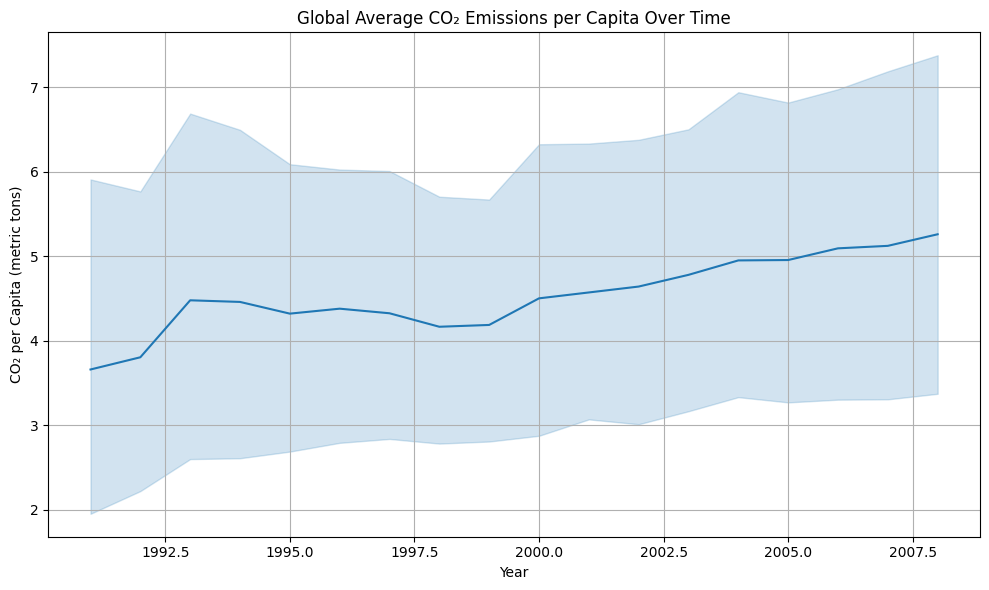

In [6]:
df_yearly_avg = data.groupby('year')['co2_per_cap'].mean().reset_index()

# Plotting the yearly average CO2 emissions per capita
plt.figure(figsize=(10,6))
sns.lineplot(data=data, x='year' , y='co2_per_cap' , markers='o')
plt.title('Global Average CO₂ Emissions per Capita Over Time')
plt.ylabel('CO₂ per Capita (metric tons)')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

📈 **Chart Elements**

- **Blue Line with Markers**: Shows the yearly global average of CO₂ emissions per capita.
- **Shaded Blue Area**: Indicates variation or uncertainty (e.g., standard deviation) among countries each year.

---

> 🧠 **Key Insights**

1. **Stable Global Average**: Values mostly range from 4.3 to 4.9 metric tons per capita.
2. **Slight Rise (1991–1994)**: Modest increase, possibly due to economic growth.
3. **Plateau (Late 1990s–2008)**: Levels remain steady with minor changes.
4. **High Country Variability**: Wide shaded area shows large differences between countries.

Overall, global per capita CO₂ emissions were steady from 1991 to 2008, but national

#### 🌐 Total CO₂ Emissions vs Population – Chart

This scatter plot illustrates the relationship between a country's **total CO₂ emissions** and its **population**.


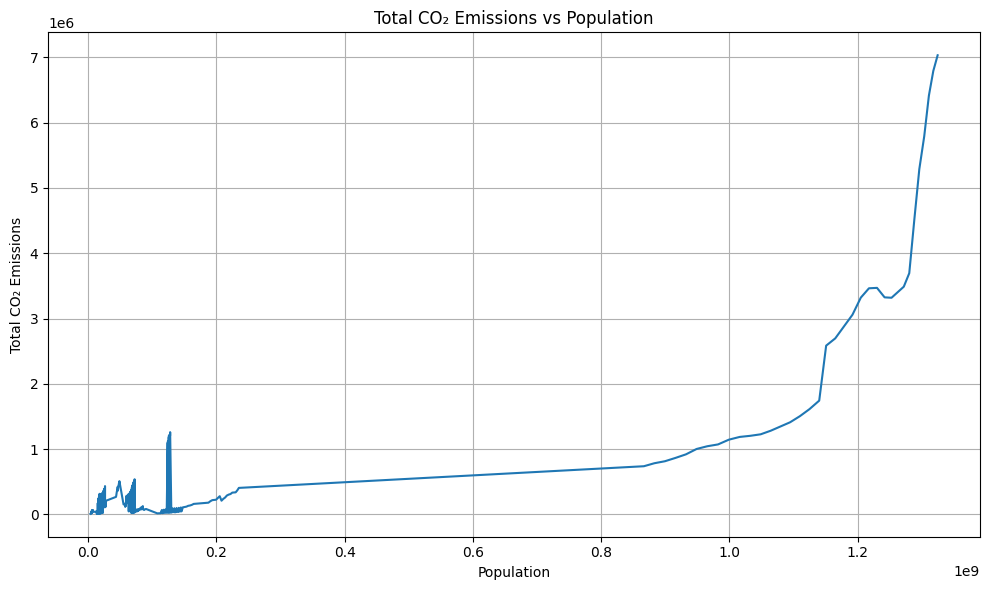

In [7]:
plt.figure(figsize=(10, 6) )
sns.lineplot(data = data , x= 'pop' , y = 'co2_ttl', markers='^')
plt.title('Total CO₂ Emissions vs Population')
plt.ylabel('Total CO₂ Emissions')
plt.xlabel('Population')
plt.grid(True)
plt.tight_layout()      
plt.show()

**Key Observations** 🔍

- **Population Effect:**  
  Larger populations usually mean higher total CO₂ emissions.

- **Major Outliers:**  
  Big jumps at ~1–1.5B (China), ~1–1.4B (India), and ~300–400M (USA).

- **Variation:**  
  Countries with similar populations can have very different emissions due to industry and energy sources.

- **Data Gaps:**  
  Sudden drops may signal missing data or big country differences.

**Summary:**  
Population size drives total CO₂ emissions, but per capita values vary, showing the impact of energy policy and development.

### 4. Hypothesis Definition

The dataset includes various country-level features categorized as:

- 🌍 **Emissions**: CO₂, CH₄, N₂O, etc.  
- 👥 **Population metrics**: total population, urban %, growth  
- 💰 **Economic indicators**: GDP, GNI, FDI  
- 🌾 **Land use**: cereal yield, agricultural land, protected areas  
- 🌦️ **Climate data**: precipitation, natural disasters  
- ⚡ **Energy use**  
- 🏥 **Health metrics**: medical personnel count  
- ...and others

---

#### 🎯 Project Goal

To explore how factors like economy, energy use, and land use influence emissions and climate indicators. Ultimately, develop a **predictive ML model** for emissions or climate data using the above features.

---

#### 📌 Hypothesis

> **CO₂ emissions are influenced by country-specific features** such as energy use, population metrics, GDP, FDI, and land use — and can be predicted from them.

In this study, **CO₂ emissions** will be treated as the **dependent variable**, and we’ll assess how it relates to other available features.

---

_Note: Some features were excluded due to high missingness during preprocessing._


## Feature engineering

In [8]:
# create a column for the total energy use
data['en_ttl'] = data['en_per_gdp'] * data['gdp'] /1000

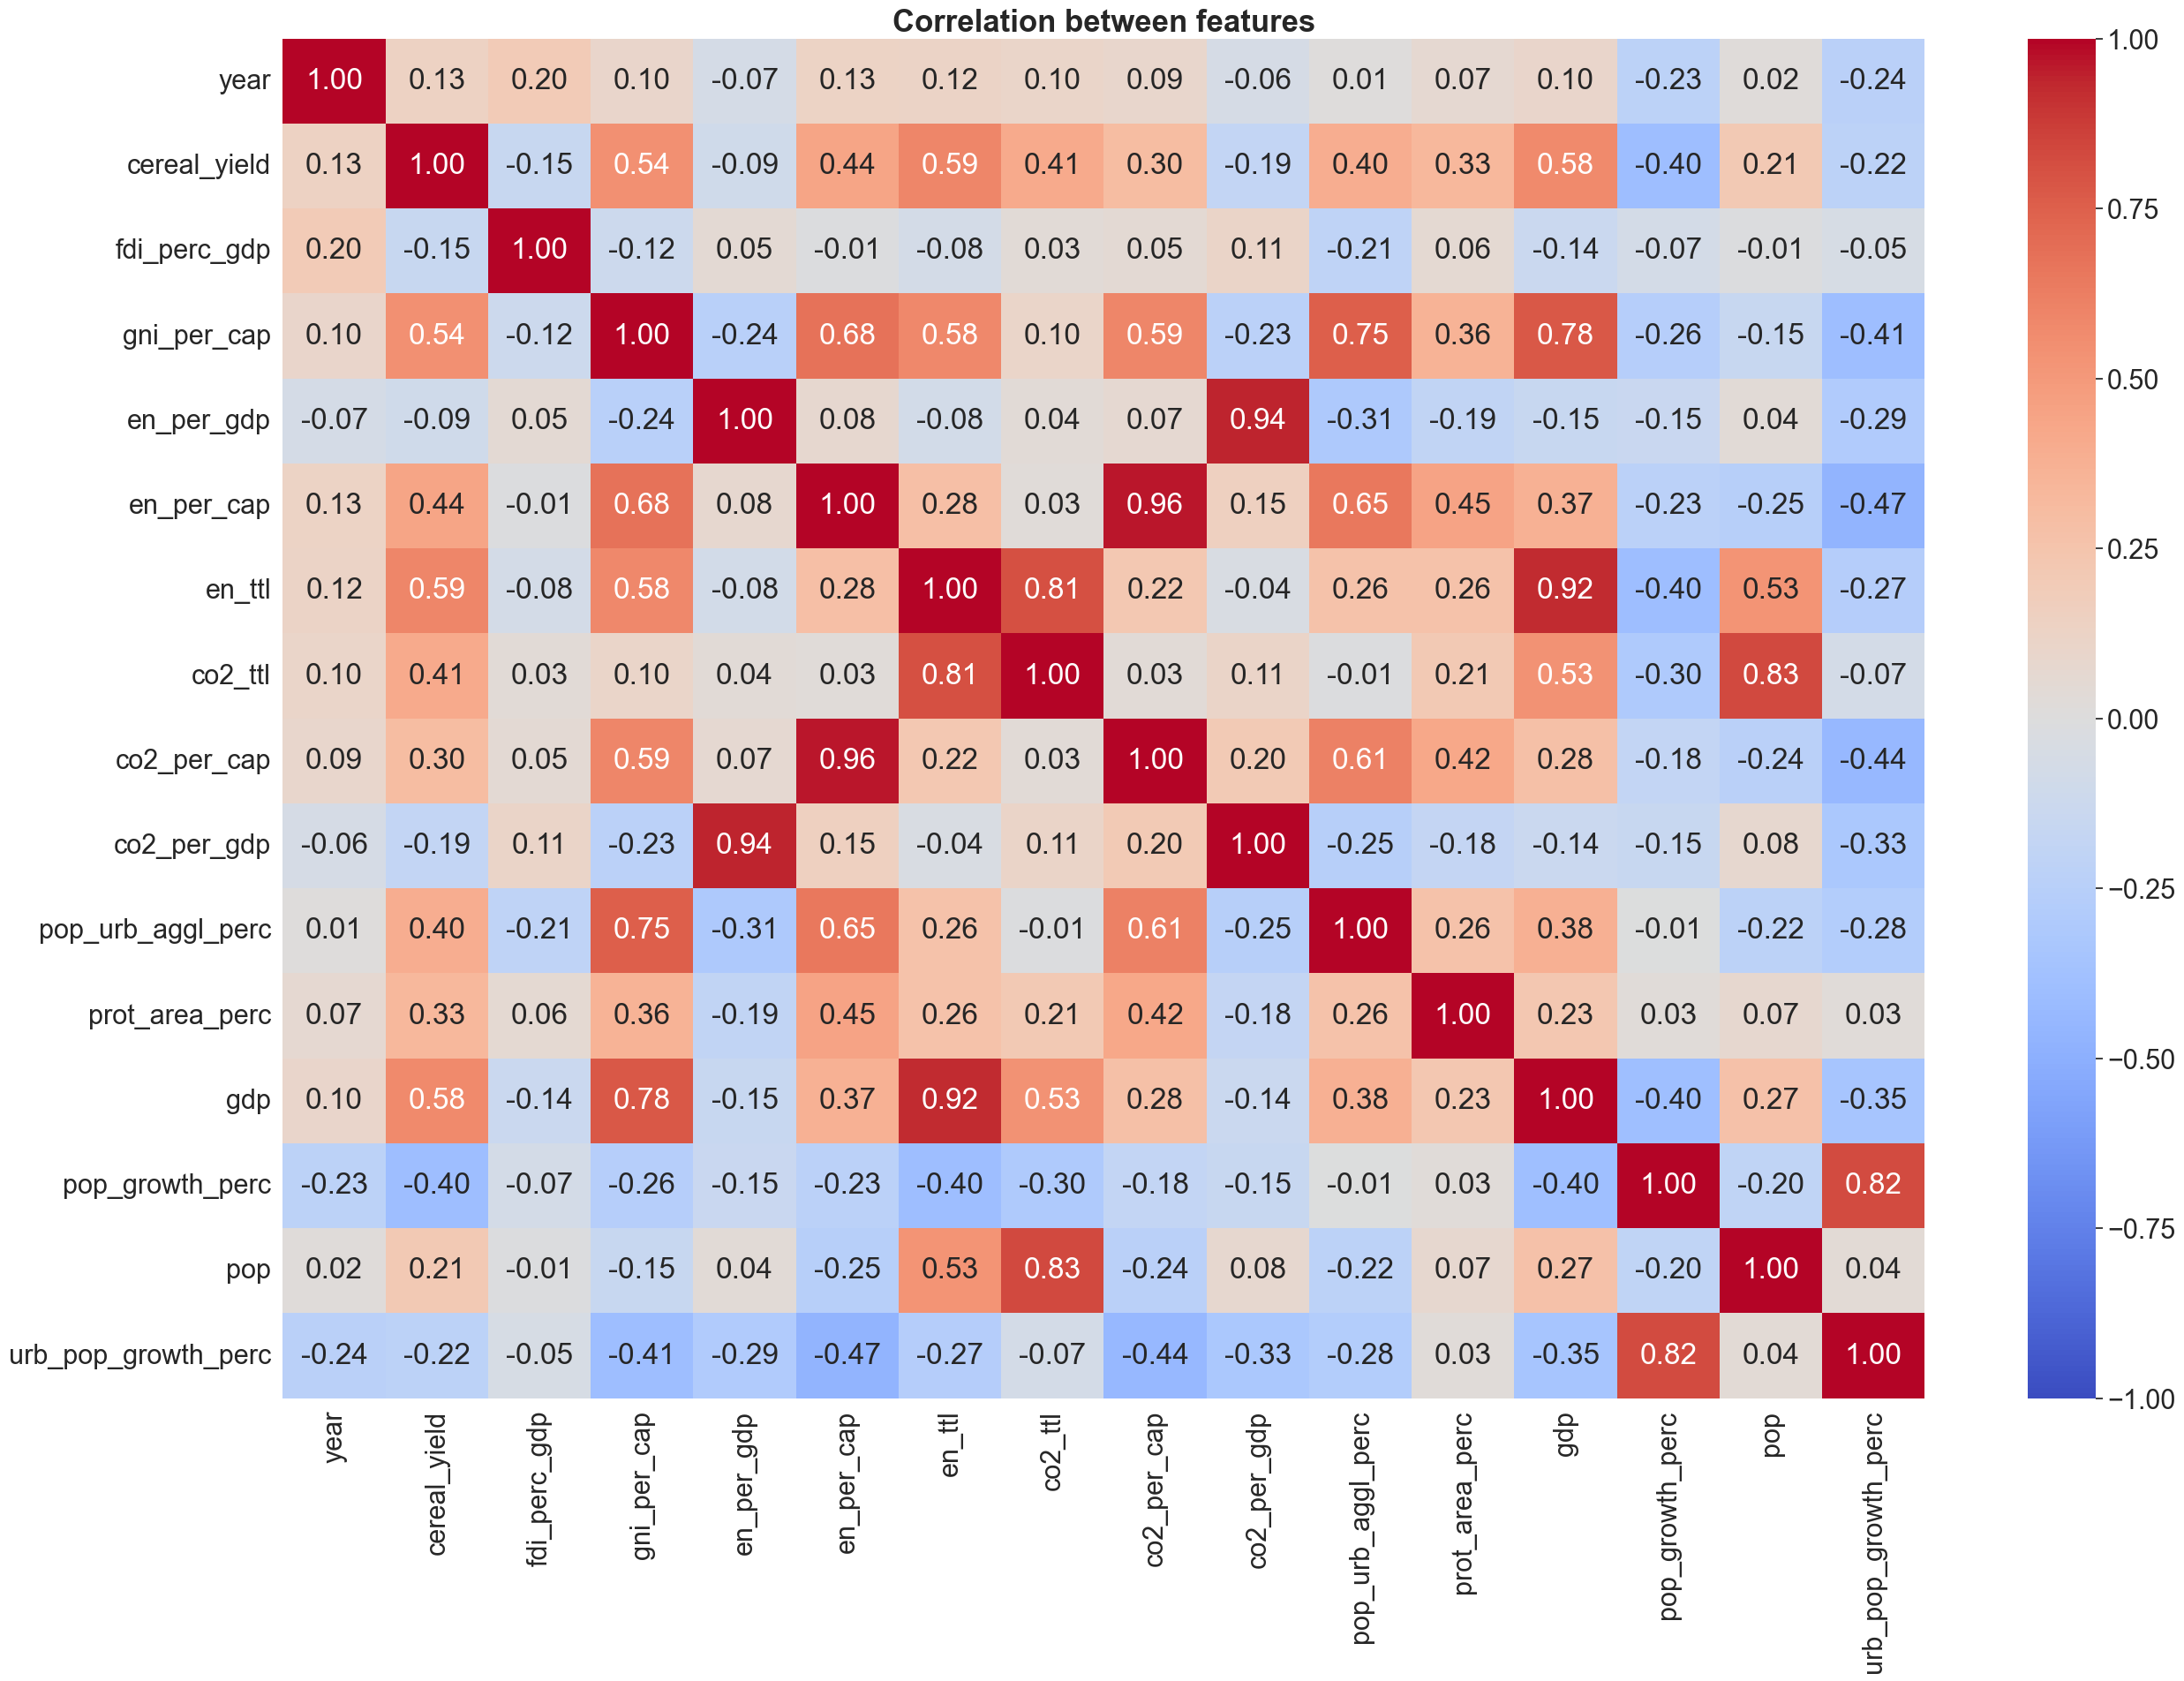

In [9]:
# select all features
features_all = data[['country','year','cereal_yield','fdi_perc_gdp','gni_per_cap',
                     'en_per_gdp', 'en_per_cap', 'en_ttl', 'co2_ttl', 'co2_per_cap',
                     'co2_per_gdp', 'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',
                     'pop_growth_perc', 'pop', 'urb_pop_growth_perc']]

# plot a correlation of all features
# correlation matrix
sns.set_theme(font_scale=2)
f,ax=plt.subplots(figsize=(30,20))
sns.heatmap(features_all.drop(['country'], axis=1).corr(), annot=True, cmap='coolwarm', fmt = ".2f", 
            center=0, vmin=-1, vmax=1)
plt.title('Correlation between features', fontsize=25, weight='bold' )
plt.show()

sns.set_theme(font_scale=1)

- When comparing the dependencies of co2_ttl, co2_per_cap, and co2_per_gdp with other features, **co2_per_cap** shows stronger correlations with more variables.

- It also reflects CO₂ emissions independent of population size, making it more useful for comparing countries of different sizes and populations.

- Since most chosen variables are already linked to population, including pop (population count) adds little value — this is also supported by its low correlation.

Based on this, the following features will be excluded from further analysis due to weak correlations: pop = -0.1, en_per_gdp = -0.1, en_ttl = 0.09, co2_per_gdp, and co2_ttl = 0.03.

In [10]:
features_for_vif = data[['cereal_yield','fdi_perc_gdp','gni_per_cap', 'en_per_cap', 'co2_per_cap',
                     'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',  'pop_growth_perc', 'urb_pop_growth_perc']]


vif_data = pd.DataFrame()
vif_data["feature"] = features_for_vif.columns # Use the columns from the features_for_vif DataFrame
vif_data["VIF"] = [variance_inflation_factor(features_for_vif.values, i)
                   for i in range(features_for_vif.shape[1])] # Use the values and number of columns from features_for_vif
print(vif_data)

               feature        VIF
0         cereal_yield   1.528133
1         fdi_perc_gdp   0.971334
2          gni_per_cap   2.910812
3           en_per_cap  12.579371
4          co2_per_cap  10.762323
5    pop_urb_aggl_perc   0.979676
6       prot_area_perc   1.022400
7                  gdp   1.106440
8      pop_growth_perc   6.336530
9  urb_pop_growth_perc   5.808288


VIF values measure how much a feature's variance is inflated due to multicollinearity with other features:

- VIF < 5 → Low multicollinearity (generally safe)

- VIF 5–10 → Moderate multicollinearity (potential issue)

- VIF > 10 → High multicollinearity (problematic, should consider dropping or combining)

In [11]:
features = features_all[['cereal_yield','fdi_perc_gdp','gni_per_cap', 'en_per_cap', 'co2_per_cap',
                     'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',  'pop_growth_perc', 'urb_pop_growth_perc']]

## Prepare the visualization

In [12]:
# a dictionary with feature labels
labels_dict = {'gni_per_cap':'GNI per capita [Atlas $]',
               'gdp':'Gross Domestic Product [$]',
               'cereal_yield':'Cereal yield [kg/ha]',
               'prot_area_perc': 'Nationally terrestrial protected areas [% of total land area]',
               'fdi_perc_gdp': 'Foreign Direct Investment [% of GDP]',
               'pop_urb_aggl_perc': 'Population in urban agglomerations > 1mln [%]',
               'urb_pop_growth_perc':'Urban population growth [annual %]',
               'pop_growth_perc': 'Population growth [annual %]',
               'co2_per_cap':'CO2 emissions per capita [t]',
               'en_per_cap':'Energy use per capita [kg oil eq]' }

In [13]:
# get unique values in country column

unique_countries = data['country'].unique()
unique_countries

array(['AGO', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'BGD', 'BGR', 'BLR',
       'BOL', 'BRA', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COG',
       'COL', 'CRI', 'CZE', 'DEU', 'DNK', 'DOM', 'DZA', 'ECA', 'ECU',
       'EGY', 'EMU', 'ESP', 'ETH', 'FIN', 'FRA', 'GBR', 'GHA', 'GRC',
       'GTM', 'HND', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'ISR', 'ITA',
       'JOR', 'JPN', 'KAZ', 'KEN', 'KOR', 'LAC', 'LIC', 'LMC', 'LMY',
       'MAR', 'MEX', 'MIC', 'MNA', 'MOZ', 'MYS', 'NGA', 'NLD', 'NZL',
       'PAK', 'PAN', 'PER', 'PHL', 'POL', 'PRT', 'PRY', 'ROM', 'RUS',
       'SAS', 'SAU', 'SDN', 'SEN', 'SLV', 'SSA', 'SWE', 'SYR', 'TGO',
       'THA', 'TUR', 'TZA', 'UKR', 'UMC', 'URY', 'USA', 'UZB', 'VEN',
       'VNM', 'WLD', 'YEM', 'ZAF', 'ZAR', 'ZMB'], dtype=object)

#### CO₂ Emissions per Capita Over Time (Selected Countries)

This line chart illustrates the **CO₂ emissions per capita** (in metric tons) over time for five selected countries: **India (IND), New Zealand (NZL), Pakistan (PAK), USA, and Russia (RUS)**, spanning from the early 1990s to 2008.


/var/folders/36/9bqbb6vx74ddlfdt031cqj2c0000gn/T/ipykernel_1817/2805705593.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/abhishekkanade/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


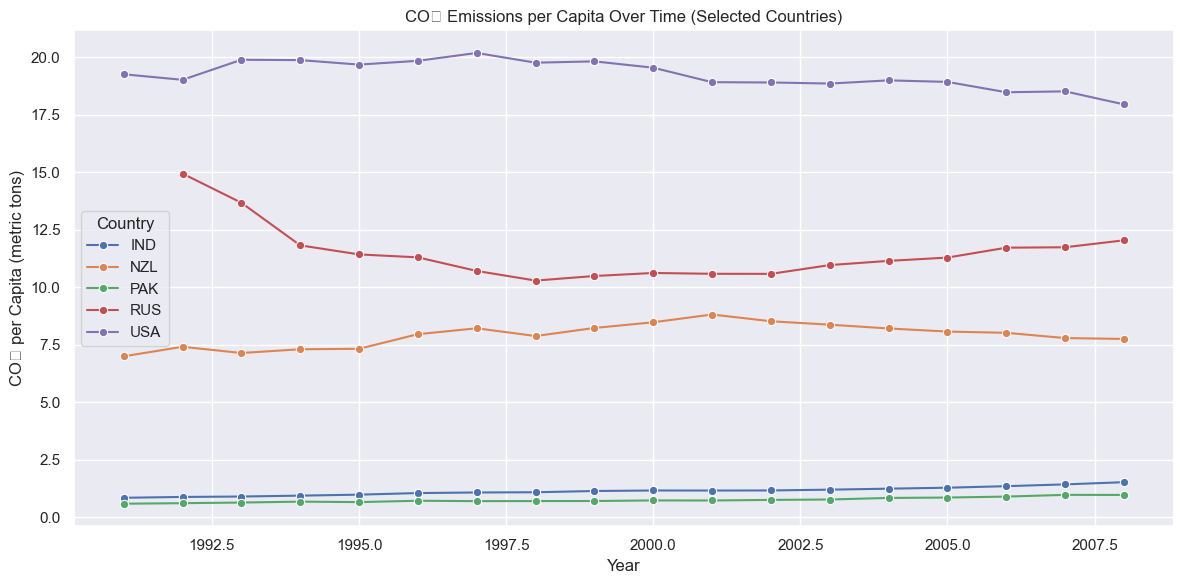

In [14]:
# Select countries to compare
selected_countries = ['IND', 'USA', 'PAK', 'RUS', 'NZL']

# Use the correct DataFrame variable 'data' and column names 'country', 'year', and 'co2_per_cap'
df_selected = data[data['country'].isin(selected_countries)]

# Plot
plt.figure(figsize=(12, 6))
# Use the correct DataFrame variable 'df_selected' and column names 'year' and 'co2_per_cap' for plotting
sns.lineplot(data=df_selected, x='year', y='co2_per_cap', hue='country', marker='o')
plt.title('CO₂ Emissions per Capita Over Time (Selected Countries)')
plt.ylabel('CO₂ per Capita (metric tons)')
plt.xlabel('Year')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

## Key Observations

- **USA**: Highest per capita emissions (**19–20 metric tons**), slight decline recently.
- **Russia (RUS)**: Sharp drop in early 1990s (economic changes), stabilizes at **11–12 metric tons**.
- **New Zealand (NZL)**: Mid-level, peaks near **9 metric tons**, then gradual decline.
- **India (IND)** & **Pakistan (PAK)**: Lowest emissions, but both show **steady increases**.

> **Insight:**  
> Developed countries have much higher per capita emissions, while emerging economies like India and Pakistan are on a gradual

In [15]:
# select only rows for half of the countries chosen randomly in order to ensure better visibility
chosen_countries=['IND', 'LMC', 'LMY', 'MAR', 'MEX', 'MIC', 'MNA', 'MOZ', 'MYS',
'NGA', 'NLD', 'NZL', 'PAK', 'PAN', 'PER', 'PHL', 'PRT', 'PRY',
'ROM', 'SAS', 'SAU', 'SDN', 'SEN', 'SLV', 'SSA', 'SWE', 'SYR',
'TGO', 'THA', 'TUR', 'TZA', 'UMC', 'URY', 'USA', 'VEN', 'VNM',
'WLD', 'ZAF', 'ZAR', 'ZMB', 'ECA', 'POL', 'RUS', 'UKR', 'YEM',
'ETH', 'BEL']

features_chosen = features_all[features_all['country'].isin(chosen_countries)]

## Create plots and visualizations

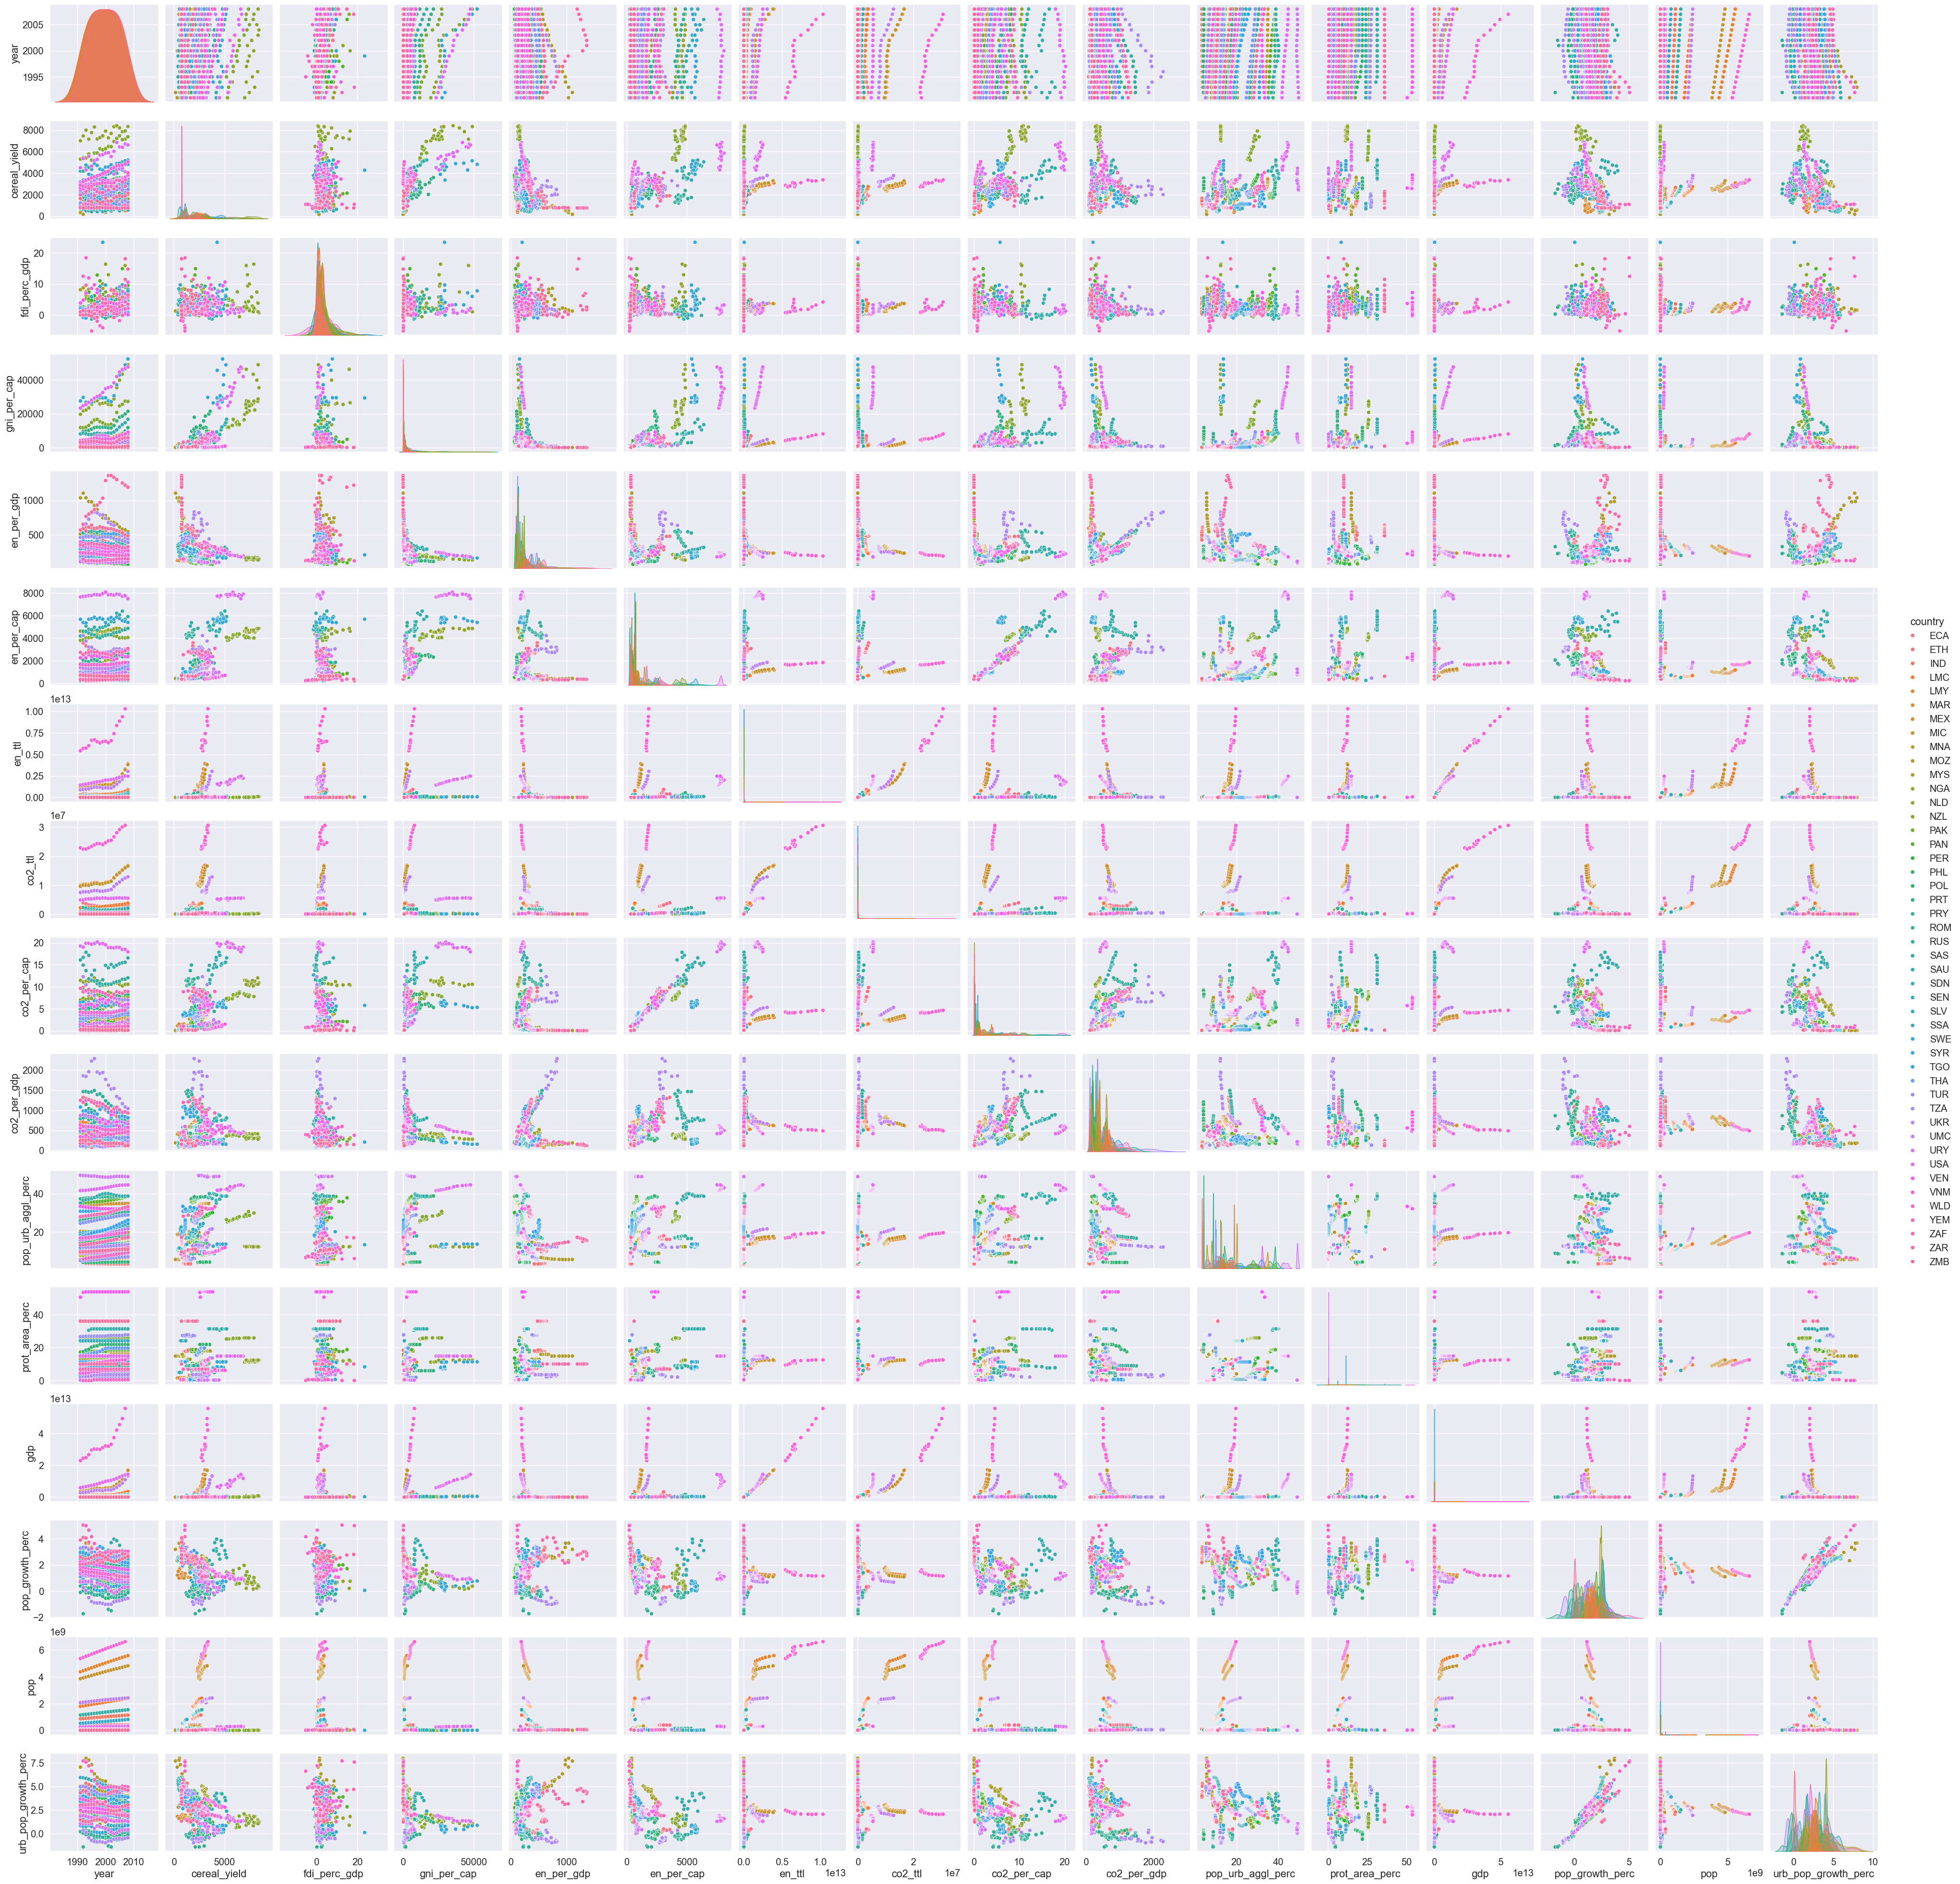

In [16]:
sns.set_theme(font_scale=1.3)
sns.pairplot(data=features_chosen, hue='country')


#### Notable Outliers: United Arab Emirates

Another significant observation is the cluster of orange outlier points with CO₂ emissions per capita ranging between **25 and 40 metric tons**, all attributed to the **United Arab Emirates (ARE)**. While there are other country-specific outliers, they do not substantially impact the overall trend.

To enhance clarity, **ARE data points were removed**, and the updated plots are presented below:


In [17]:
# choose features and label columns
feature_cols = ['country', 'cereal_yield','fdi_perc_gdp','gni_per_cap', 'en_per_cap', 'pop_urb_aggl_perc',
                    'prot_area_perc', 'gdp',  'pop_growth_perc', 'urb_pop_growth_perc', 'co2_per_cap']

# Keep as DataFrame for filtering
features_for_plot = data[feature_cols].copy() # Create a copy to avoid SettingWithCopyWarning

# remove the ARE outliers from the DataFrame used for plotting
features_for_plot = features_for_plot[features_for_plot['country']!='ARE']

Text(107.67453906249999, 0.5, 'CO2 emissions per capita [t]')

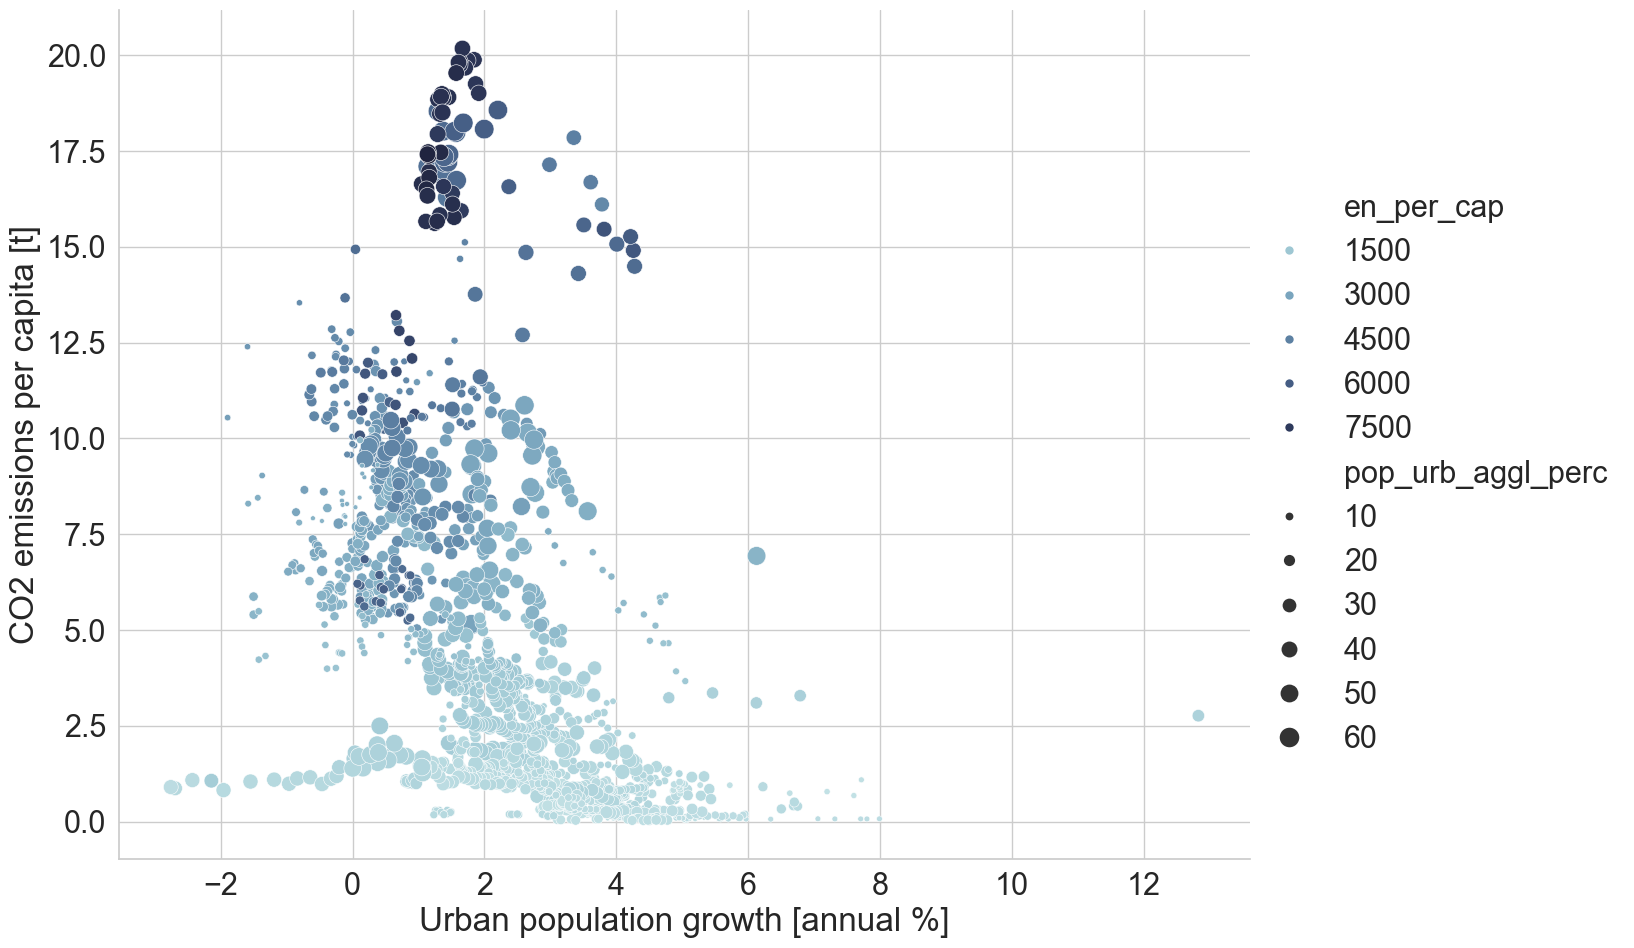

In [18]:
# 4d plot

sns.set_theme(style="whitegrid", font_scale=2)

cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)
g = sns.relplot(
    data=features_for_plot, # Use the DataFrame specifically prepared for plotting
    x="urb_pop_growth_perc", y="co2_per_cap",
    hue="en_per_cap", size="pop_urb_aggl_perc",
    palette=cmap, sizes=(10, 200),
    height=10, aspect= 4/3
)

g.ax.set_xlabel(labels_dict['urb_pop_growth_perc'])
g.ax.set_ylabel(labels_dict['co2_per_cap'])

***

#### **Conclusions**

Targeted plotting of key relationships has provided useful insights for predictive analysis:

* CO₂ emissions and energy use per capita are linked to more features and will be kept for further analysis.

* Population count is no longer relevant and will be removed.

* CO₂ emissions per capita show a strong linear relationship with energy use and nonlinear patterns with other variables.

* Both country-specific and overall global trends are visible. In some cases, global trends split into different paths for clusters of countries.

* Outlier groups, especially those from the United Arab Emirates (ARE), stand out from global patterns and should be considered when selecting data.

* The nonlinear nature of most relationships and the presence of country-based clusters suggest using machine learning models that handle nonlinearities and grouped data well (e.g., Random Forest), rather than those suited for purely linear patterns (e.g., Linear Regression).

***
